In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import ttest_ind

tad_boundaries = pd.read_csv('wt-boundary.bed', sep='\t', header=None, names=['chrom', 'start', 'end'])

In [ ]:
tad_boundaries.sort_values(['chrom', 'start'], inplace=True)

tad_regions = []

for chrom, group in tad_boundaries.groupby('chrom'):
    boundaries = group['start'].values
    
    if len(boundaries) < 2:
        continue
    
    for i in range(len(boundaries) - 1):
        tad_start = boundaries[i]
        tad_end = boundaries[i + 1]
        tad_regions.append({'chrom': chrom, 'start': tad_start, 'end': tad_end})
        
tad_df = pd.DataFrame(tad_regions)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(1234)

expr_df = pd.read_csv('wt-exp-5k.bed', sep='\t', 
                      header=None, names=['start', 'end', 'expression','bin'])

tad_expression_data = []

tad_bin_counts = [] 

for index, tad in tad_df.iterrows():
    bins_in_tad = expr_df[
        (expr_df['start'] >= tad['start']) &
        (expr_df['end'] <= tad['end'])
    ]
    
    if not bins_in_tad.empty:
        expressions = bins_in_tad['expression'].values
        tad_expression_data.append({
            'tad_id': f"TAD_{index}",
            'expressions': expressions,
            'mean_expression': np.mean(expressions),
            'variance_expression': np.var(expressions)
        })
        # 记录 TAD 内部的 bin 数目
        tad_bin_counts.append(len(bins_in_tad))

tad_expr_df = pd.DataFrame(tad_expression_data)

tad_expr_df.to_csv('tad_expression_data.csv', index=False)

num_random_samples = 50  
num_tads = len(tad_expr_df)

total_tad_bins = sum(tad_bin_counts)  

random_variances = []

for i in range(num_random_samples):
    random_bins = expr_df.sample(n=total_tad_bins, replace=False).reset_index(drop=True)
    
    start_idx = 0
    variances = []
    random_bin_groups = []
    for count in tad_bin_counts:
        end_idx = start_idx + count
        random_group = random_bins.iloc[start_idx:end_idx]
        random_bin_groups.append(random_group)
        random_group_expressions = random_group['expression'].values
        variance = np.var(random_group_expressions)
        variances.append(variance)
        start_idx = end_idx
    group_df = pd.concat(random_bin_groups)
    group_df.to_csv(f'./random_cids/random_bin_group_sample_{i}.csv', index=False)
    random_mean_variance = np.mean(variances)
    random_variances.append(random_mean_variance)
    pd.DataFrame({'random_mean_variance': [random_mean_variance]}).to_csv(f'./random_cids/random_variance_sample_{i}.csv', index=False)

tad_mean_variance = tad_expr_df['variance_expression'].mean()

random_mean_variance = np.mean(random_variances)

pd.DataFrame({'random_mean_variance': random_variances}).to_csv('random_variances.csv', index=False)

t_stat, p_value = ttest_ind(tad_expr_df['variance_expression'], random_variances, equal_var=False)

print(f"Mean variance within TADs: {tad_mean_variance}")
print(f"Mean variance from random bins: {random_mean_variance}")
print(f"T-test statistic: {t_stat}")
print(f"P-value: {p_value}")

Mean variance within TADs: 329849954812124.1
Mean variance from random bins: 706481141013976.5
T-test statistic: -2.3580078271573175
P-value: 0.025434403700332512


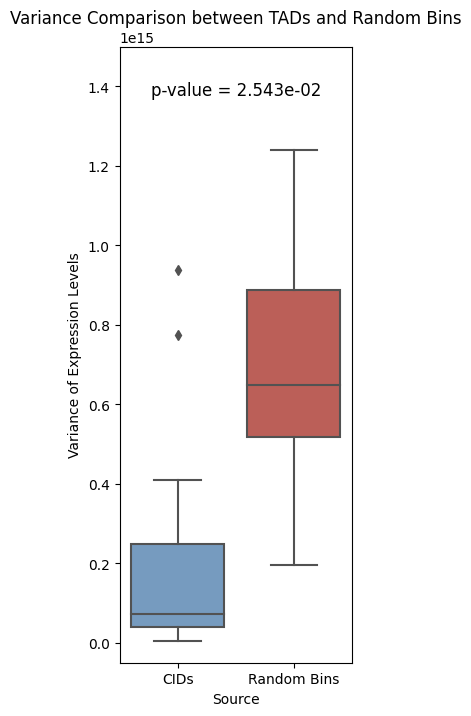

In [ ]:
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'


data_to_plot = pd.DataFrame({
    'Variance': list(tad_expr_df['variance_expression']) + list(random_variances),
    'Source': ['CIDs'] * len(tad_expr_df) + ['Random Bins'] * len(random_variances)
})

plt.figure(figsize=(3, 8))
sns.boxplot(x='Source', y='Variance', data=data_to_plot, palette=('#6a9bcb', '#cb5148'),showfliers=True)

plt.text(0.5, max(data_to_plot['Variance']) * .34, f'p-value = {p_value:.3e}',
         ha='center', va='bottom', fontsize=12)
plt.ylim(-0.5e14,1.5e15)
plt.ylabel('Variance of Expression Levels')
plt.title('Variance Comparison between TADs and Random Bins')
plt.savefig('variance_comparison_boxplot.pdf')
plt.show()

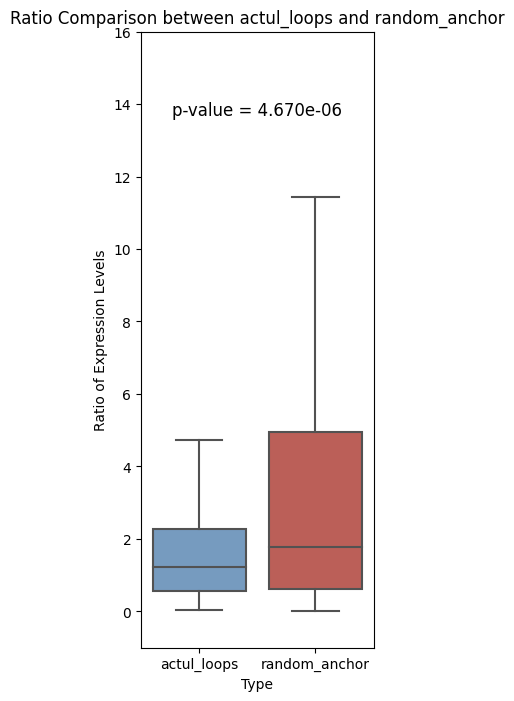

In [ ]:
ratio_ab_values = None
ratio_ac_values = []

for i in range(1, 11):
    df = pd.read_csv(f'./Loop-coexpression/loop_expression_ratios_{i}.csv')
    if ratio_ab_values is None:
        ratio_ab_values = df['ratio_AB']
    ratio_ac_values.extend(df['ratio_AC'])

data_to_plot_ratios = pd.DataFrame({
    'Ratio': list(ratio_ab_values) + ratio_ac_values,
    'Type': ['actul_loops'] * len(ratio_ab_values) + ['random_anchor'] * len(ratio_ac_values)
})

ratio_t_stat, ratio_p_value = ttest_ind(ratio_ab_values, ratio_ac_values, equal_var=False)

plt.figure(figsize=(3, 8))
sns.boxplot(x='Type', y='Ratio', data=data_to_plot_ratios, palette=('#6a9bcb', '#cb5148'),showfliers=False)
# sns.boxplot(x='Source', y='Variance', data=data_to_plot, palette=('#6a9bcb', '#cb5148'),showfliers=False)

plt.text(0.5, max(data_to_plot_ratios['Ratio']) * 0.15, f'p-value = {ratio_p_value:.3e}',
         ha='center', va='bottom', fontsize=12)

plt.ylabel('Ratio of Expression Levels')
plt.ylim(-1,16)
plt.title('Ratio Comparison between actul_loops and random_anchor')
plt.savefig('ratio_comparison_boxplot.pdf')
plt.show()

In [42]:
data_to_plot_ratios.to_csv('random_loop_Exp.csv')